# Fem para la ecuación de Poisson gravitacional

Santiago Andrés Acosta Díaz


El ejercicio pide resolver la ecuación de Poisson en simetría esférica

$$
    \frac{1}{r^2} \frac{d}{dr} \left( r^2 \frac{d\Phi}{dr} \right) = 4 \pi G \rho(r)
$$

con $\rho(r) = \rho_c \left( 1 - \left(\frac{r}{R}\right)^2 \right)$, $\rho_c = 10^5 \, \frac{Kg}{m^3}$, $R = 7\times10^8 \, m$.

## Reformular como problema variacional 



Para poder utilizar FEM, se tiene que reformular la ODE como un problema variacional. Esto es, aunque no muy formalmente, hacer que esta ecuación se convierta en una ecuación integral. La razón de esto es que, a diferencia de diferencias finitas donde aproximamos únicamente puntos en los nodos de la malla, en FEM se busca hacer que el interior de la malla obedezca alguna física. Es por esto que, al integrar el espacio al interior de la malla, ahora hacemos que el espacio entero entre nodos contenga información física dada por la ODE original. 

También, para hacer esta reformulación se suele multiplicar la ODE entera por una función de prueba $v(r)$ que pertenece al espacio de todas las funciones de prueba posibles, que se toman como una suerte de "pesos". Esto se hace para que el residuo de la ecuación homogenea, al integrarse por cualquiera sea el peso, resulte en 0, significando que el $\Phi$ restaurado satisface la ecuación integral pero no necesariamente la ODE punto por punto. (Ojalá me haya explicado bien).


Para empezar esta reformulación, reescribimos la ecuación como

$$
    \partial_r \left(r^2 \partial_r \Phi \right) = 4 \pi G \rho(r) r^2,
$$

multiplicamos por la función de prueba e integramos en el dominio

$$
    \int_0^R \, p(r) \, \partial_r \left(r^2 \partial_r \Phi \right) \, dr = 4 \pi G \int_0^R \, p(r) \, \rho(r) r^2 \, dr
$$

Aplicamos el teorema de la vaca vestida de uniforme al lado izquierdo con $u=p(r)$ y $dv = \partial_r \left(r^2 \partial_r \Phi \right) \, dr$

$$
    \left. p(r) \, r^2 \partial_r \Phi \right|_0^R -\int_0^R \, r^2 \partial_r \Phi \partial_r p(r) \, dr = 4 \pi G \int_0^R \, p(r) \, \rho(r) r^2 \, dr
$$

El primer término de la izquierda, con $r=0$ resulta en $0$ por el $r^2$, pero resulta ser la condición de frontera en $r = R$, por lo que reescribimos.

$$
    \int_0^R \, r^2 \partial_r \Phi \partial_r p(r) \, dr = p(R) \, R^2 \partial_r \Phi(R) - 4 \pi G \int_0^R \, p(r) \, \rho(r) r^2 \, dr
$$


Esta anterior es como tal la _forma débil de la ecuación_. 

## Discretización de la forma débil

Sin embargo, para utilizarla en FEM debemos discretizar, y esto lo hacemos al definir la función de prueba $p(r)$, que será igual a las functiones de forma lineales para cada uno de los nodos $r_i$ tal que 

$$
    \Phi(r) \approx \sum_{i=0}^N \Phi(r_i) N_i(r)
$$

talque $N_i(r_i) = 1$ y $N_i(r_j) = 0, \,\, \forall j \ne i$. Con esto, podemos proponer

$$
    N_i(r) = \left\{ \begin{matrix}
        \frac{r - r_{i-1}}{r_i - r_{i-1}}, \quad r_{i-1} \le r \le r_i \\
        \frac{r_{i+1} - r}{r_{i+1} - r_{i}}, \quad r_{i} \le r \le r_{i+1} \\
        0, \qquad e.o.c
    \end{matrix} \right.
$$

Reemplazando esta aproximación en la forma débil, llegamos a que

$$
    \sum_{i=1}^{N} \Phi_i \int_{0}^R \, r^2 \partial_r N_i(r) \partial_r N_j(r) \, dr = N_j(R) \, R^2 \partial_r \Phi(R) - 4 \pi G \int_0^R \, N_j(r) \, \rho(r) r^2 \, dr
$$

y teniendo que 

$$
    \partial_r N_i(r) = \left\{ \begin{matrix}
        \frac{1}{h}, \quad r_{i-1} \le r \le r_i \\
        -\frac{1}{h}, \quad r_{i} \le r \le r_{i+1} \\
        0, \qquad e.o.c
    \end{matrix} \right.
$$

considerando que la malla está equiespaciada con $\Delta r = h$.

## Escribir algebráicamente

Por último, escribimos esto de forma algebráica, donde la variable desconocida es el vector de los $\Phi_i$. Para esto, definimos la matrix de estres 

$$
    K_{ji} = \int_{0}^R \, r^2 \partial_r N_i(r) \partial_r N_j(r) \, dr
$$

La condición de frontera es un vector donde sólo su última entrada tiene un valor $R^2 \partial_r \Phi(R)$. Sin embargo, vamos a utilizar una condición de Dirichlet donde 

$$
    \Phi(R) = -2\pi G \rho_c R^2 \left(\frac{1}{6} + \frac{1}{20} \right)
$$

que viene dada de evaluar la solución analítica en la frontera. Entonces, con esto, simplemente forzamos el último nodo a tener este valor.

Y creamos el vector de sources

$$
    F_j = -4\pi G \int_0^R N_j(r) \rho(r) r^2 \, dr
$$


Finalmente, obtenemos el __SISTEMA A RESOLVER__

$$
\boxed{
    K \vec \Phi = \vec F
}
$$

### Condiciones de frontera

Para las condiciones de frontera que vamos a usar, simplemente vamos a hacer el elemento $K_{NN} = 1$ y todos los demás de su fila $0$, mientras que $F_N = \Phi(r)$. Esto asegura la condición de frontera de Dirichlet.

## Implementación del código

In [46]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Constantes
rho_c = 10**5
R = 7e8
G = 6.6743e-11

# Funciones del sistema como tal
def rho(r):
    return rho_c * (1. - (r / R)**2)
    
def create_K(j, i, N):
    """ Crea el elemento K_ij de la matrix K """

    # primero, revisamos si este elemento simplemente es diferente de 0, es decir, tenemos is y js no contiguos
    if abs(i - j) > 1:
        return 0.0
    elif i == (N-1):
        if (j == (N-1)):
            return 1.0   # Condición de Dirichlet
        else:
            return 0.0

    if i == j:
        # Computamos las diagonales
        # En general, si i==j tenemos que la contribución de las Ns es positivas, mientras que es negativa en caso contrario
        sign = 1.0
        # Ahora tenemos que revisar los límites de integración: básicamente, el rango del elemento en donde estamos
        lims = np.sort([rs[i-1], rs[i+1]])

        if i==0:
            # En el caso de la primera entrada
            lims = np.sort([rs[i], rs[i+1]])
    else:
        sign = -1.0
        lims = np.sort([rs[i], rs[j]])

    # En este caso, el integrante es una constante * r^2. Entonces la integral es simplemente
    # Creamos el integrante
    integral = (sign / (h**2)) * ((lims[1]**3 - lims[0]**3) / 3.)

    # Retornamos el elemento
    return integral


def create_F(i, N):
    """ Esta función crea el elemento i-ésimo de F """

    if i == (N-1):
        # Condición de Dirichlet
        # return -2. * np.pi * G * rho_c * R**2 * ((1./6.) - (1. / 20.))
        return anal_sol(R)


    # Creamos la función de forma
    def N(r):
        if r < rs[i]:
            return (r - rs[i-1])/h
        else:
            return (rs[i+1] - r)/h

    # Creamos el integrando 
    integrant = lambda r: N(r) * rho(r) * r**2

    # Creamos los límites
    if i == 0:
        lims = [0.0, rs[1]]
    else:
        lims = [rs[i-1], rs[i+1]]

    # Integramos
    F, _ = quad(integrant, lims[0], lims[1])

    return - 4. * np.pi * G * F

Ahora, creamos los sistemas

In [47]:
def solve_system(N):
    # Malla
    global rs, h
    
    rs = np.linspace(0, R, N)
    h = R/(N-1)
    
    # Creamos la matrix K y F
    K = np.zeros((N, N))
    F = np.zeros(N)
    
    for j in range(N):
        F[j] = create_F(j, N)
        for i in range(N):
            K[i, j] = create_K(j, i, N)
    
    
    # Resolvemos el sistema
    PHIs = np.linalg.solve(K, F)

    # Retornamos la respuesta
    return rs, PHIs


## Corroboración

Ahora, creamos su solución analítica.

__NOTA IMPORTANTE:__ al parecer hay un tipo en la solución analítica propuesta en las diapos, donde falta multiplicar por un 2.


In [48]:
anal_const = -4. * np.pi * G * rho_c

def anal_sol(r):
    return anal_const * ( ((R**2) / 3.) - ((r**2) / 6.) + ((r**4) / (20. * (R**2)) ))

# Solución

Ahora que ya tenemos todo lo necesario, vemos las soluciones

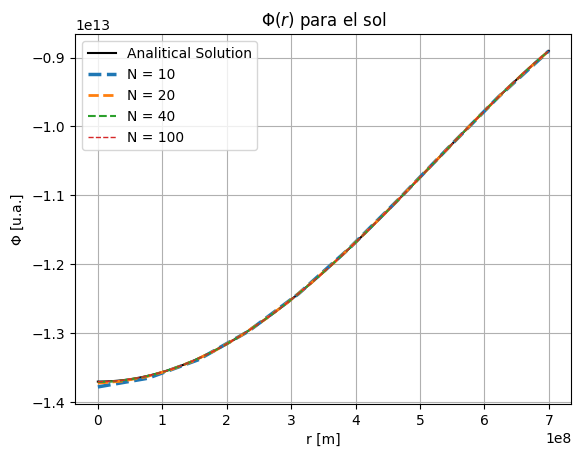

In [52]:
rs10, PHI10 = solve_system(10)
rs20, PHI20 = solve_system(20)
rs40, PHI40 = solve_system(40)
rs100, PHI100 = solve_system(100)

rs_anal = np.linspace(0., R, 100)
PHI_anal = anal_sol(rs_anal)


# Creamos las gráficas
plt.title(r"$\Phi(r)$ para el sol")
plt.xlabel("r [m]")
plt.ylabel("$\Phi$ [u.a.]")
plt.plot(rs_anal, PHI_anal, c = "black", lw = 1.5, label = "Analitical Solution")
plt.plot(rs10, PHI10, "--", lw = 2.5, label = "N = 10")
plt.plot(rs20, PHI20, "--", lw = 2.0, label = "N = 20")
plt.plot(rs40, PHI40, "--", lw = 1.5, label = "N = 40")
plt.plot(rs100, PHI100, "--", lw = 1.0, label = "N = 100")
plt.legend()
plt.grid()
plt.show()

Podemos ver que, en general, incluso para las particiones tan pequeñas que estamos considerando, los resultados son muy fieles a la solución analítica.

## Cálculo de la gravedad superficial

Para hacer esto, vamos simplemente a usar el gradiente que proporciona `numpy` y comparar con el valor real

$$
    g_{sup} \approx 274 \, \frac{m}{s^2}
$$

In [58]:
g = np.gradient(PHI100, rs100)[-1]

print(f"Aceleración en la superficie del sol usando FEM con N=100 es: g = {-g}")

Aceleración en la superficie del sol usando FEM con N=100 es: g = -7905.642338235823


El resultado anterior se aleja por montones de lo observado. Sin embargo, esto puede ser resultado muy esperado del valor de las constantes que estamos manejando, especialmente, de la densidad del centro $\rho_c$. Cambiando esta densidad a una más razonable, podemos reproducir el valor que buscamos.

In [60]:
rho_c = 3500 # Kg / m^3
rs100, PHI100 = solve_system(100)
g = np.gradient(PHI100, rs100)[-1]

print(f"Aceleración en la superficie del sol usando FEM con N=100 es: g = {-g}")

Aceleración en la superficie del sol usando FEM con N=100 es: g = -276.6974818397289


Mucho más cercano al valor que buscamos y con mayor sentido físico, considerando que la densidad media del sol es de $\rho_c \approx 1400 \, \frac{Kg}{m^3}$, casi dos órdenes de magnitud menos que lo que estábamos usando.